# Verify n-vector Petterssen with vertify cases

Objective: reuse the same manufactured-solution validation cases from `vertify.ipynb` to test
`lagranto_nvec_petterssen.py` using **Petterssen vs exact solution** under production stepping.

Scope in this notebook:
- Case 1: dt sweep convergence (`substeps='auto'`)
- Case 1b: substep sensitivity and error attribution
- Case 2: 2D trajectory comparison
- Case 3: 3D trajectory comparison
- Case 4: high-latitude (Lat70) stress test

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lagranto_nvec_petterssen import track_particles_petterssen, ParticleStatus

# -----------------------------
# Global manufactured-case setup
# -----------------------------
R = 3396200.0  # Mars-like radius (m)

T_period = 21600.0
Omega = 2.0 * np.pi / T_period

t_end = 18000.0  # 5 hours

A_deg = 2.0
A = np.deg2rad(A_deg)

W = 0.2  # m/s

dt_list = [1200.0, 600.0, 300.0, 150.0, 75.0]

# Production integration configuration
PROD_SUBSTEPS = 'auto'
PROD_PETTERSSEN_ITERS = 3
PROD_W_POSITIVE_UP = True
PROD_PERIODIC_LON = 'auto'

print('Production config:')
print(f'  PROD_SUBSTEPS={PROD_SUBSTEPS!r}')
print(f'  PROD_PETTERSSEN_ITERS={PROD_PETTERSSEN_ITERS}')
print(f'  PROD_W_POSITIVE_UP={PROD_W_POSITIVE_UP}')
print(f'  PROD_PERIODIC_LON={PROD_PERIODIC_LON!r}')

np.set_printoptions(precision=6, suppress=True)

Production config:
  PROD_SUBSTEPS='auto'
  PROD_PETTERSSEN_ITERS=3
  PROD_W_POSITIVE_UP=True
  PROD_PERIODIC_LON='auto'


In [2]:
# -----------------------------
# Base grids and initial particles
# -----------------------------
lon_grid = np.arange(0.0, 361.0, 20.0)
lat_grid = np.linspace(-5.0, 5.0, 401)
alt_grid = np.linspace(0.0, 20000.0, 11)

lower_boundary = float(alt_grid.min())
upper_boundary = float(alt_grid.max())

init_points = [
    (350.0, 0.0, 5000.0),
    (10.0, 1.0, 8000.0),
    (180.0, -2.0, 10000.0),
]

In [3]:
# -----------------------------
# Exact solution and manufactured wind field
# -----------------------------
def exact_helix(t, lon0_deg, lat0_deg, alt0_m, *, A_deg_local=A_deg):
    t = np.asarray(t, dtype=np.float64)
    lon = (lon0_deg + np.rad2deg(Omega * t)) % 360.0
    lat = lat0_deg + A_deg_local * np.sin(Omega * t)
    alt = alt0_m + W * t
    return lon, lat, alt


def build_wind_fields(
    time_s,
    alt_grid_local=None,
    lat_grid_local=None,
    lon_grid_local=None,
    *,
    A_rad_local=A,
):
    time_s = np.asarray(time_s, dtype=np.float64)
    alt_grid_local = alt_grid if alt_grid_local is None else np.asarray(alt_grid_local, dtype=np.float64)
    lat_grid_local = lat_grid if lat_grid_local is None else np.asarray(lat_grid_local, dtype=np.float64)
    lon_grid_local = lon_grid if lon_grid_local is None else np.asarray(lon_grid_local, dtype=np.float64)

    tn = time_s.size
    zn = alt_grid_local.size
    yn = lat_grid_local.size
    xn = lon_grid_local.size

    rho = (R + alt_grid_local)[:, None, None]

    lat_rad = np.deg2rad(lat_grid_local)[None, :, None]
    u_zy1 = rho * np.cos(lat_rad) * Omega
    u_zyx = np.broadcast_to(u_zy1, (zn, yn, xn))

    u = np.empty((tn, zn, yn, xn), dtype=np.float64)
    u[:] = u_zyx[None, :, :, :]

    v = np.empty((tn, zn, yn, xn), dtype=np.float64)
    cos_term = np.cos(Omega * time_s)
    for it, c in enumerate(cos_term):
        v_z = (R + alt_grid_local) * (A_rad_local * Omega * c)
        v[it, :, :, :] = v_z[:, None, None]

    w = np.full((tn, zn, yn, xn), W, dtype=np.float64)

    return u, v, w

In [4]:
# -----------------------------
# Error and math helpers
# -----------------------------
def make_time_grid(dt, t_end_local):
    dt = float(dt)
    t_end_local = float(t_end_local)

    if (not np.isfinite(dt)) or dt <= 0.0:
        raise ValueError('dt must be finite and > 0')
    if (not np.isfinite(t_end_local)) or t_end_local < 0.0:
        raise ValueError('t_end must be finite and >= 0')

    n = int(np.round(t_end_local / dt))
    if abs(n * dt - t_end_local) > 1e-12:
        raise ValueError('t_end must align exactly with dt (integer number of steps)')

    return np.linspace(0.0, t_end_local, n + 1, dtype=np.float64)


def sph_to_xyz_vec(lon_deg, lat_deg, alt_m):
    lon = np.deg2rad(np.asarray(lon_deg, dtype=np.float64))
    lat = np.deg2rad(np.asarray(lat_deg, dtype=np.float64))
    alt = np.asarray(alt_m, dtype=np.float64)

    r = R + alt
    clat = np.cos(lat)

    x = r * clat * np.cos(lon)
    y = r * clat * np.sin(lon)
    z = r * np.sin(lat)
    return np.column_stack((x, y, z))


def compute_path_error_m(num_series, exact_series):
    lon_num, lat_num, alt_num = [np.asarray(a, dtype=np.float64) for a in num_series]
    lon_ex, lat_ex, alt_ex = [np.asarray(a, dtype=np.float64) for a in exact_series]

    if lon_num.shape != lon_ex.shape:
        raise ValueError('num and exact series must have the same shape')

    err = np.full(lon_num.shape, np.nan, dtype=np.float64)
    finite = (
        np.isfinite(lon_num)
        & np.isfinite(lat_num)
        & np.isfinite(alt_num)
        & np.isfinite(lon_ex)
        & np.isfinite(lat_ex)
        & np.isfinite(alt_ex)
    )

    if np.any(finite):
        xyz_num = sph_to_xyz_vec(lon_num[finite], lat_num[finite], alt_num[finite])
        xyz_ex = sph_to_xyz_vec(lon_ex[finite], lat_ex[finite], alt_ex[finite])
        err[finite] = np.linalg.norm(xyz_num - xyz_ex, axis=1)

    return err


def rms_final_error(traj_list, t_end_local, init_points_local):
    final_dict = traj_list[-1]
    errs = []
    for pid, (lon0, lat0, alt0) in enumerate(init_points_local):
        lon_true, lat_true, alt_true = exact_helix(t_end_local, lon0, lat0, alt0)
        lon_num, lat_num, alt_num = final_dict[pid]

        xyz_num = sph_to_xyz_vec([lon_num], [lat_num], [alt_num])[0]
        xyz_true = sph_to_xyz_vec([lon_true], [lat_true], [alt_true])[0]
        errs.append(np.linalg.norm(xyz_num - xyz_true))

    errs = np.asarray(errs, dtype=np.float64)
    return float(np.sqrt(np.mean(errs ** 2)))


def observed_order(errors, dts):
    errors = np.asarray(errors, dtype=np.float64)
    dts = np.asarray(dts, dtype=np.float64)

    out = []
    for i in range(len(errors) - 1):
        out.append(np.log(errors[i] / errors[i + 1]) / np.log(dts[i] / dts[i + 1]))
    return np.asarray(out, dtype=np.float64)

In [5]:
# -----------------------------
# Trajectory extraction, status checks, and plotting helpers
# -----------------------------
def extract_particle_series(step_list, init_points_local, pid, include_initial=True):
    if pid < 0 or pid >= len(init_points_local):
        raise IndexError(f'pid={pid} out of range')

    lon_vals = []
    lat_vals = []
    alt_vals = []

    if include_initial:
        lon0, lat0, alt0 = init_points_local[pid]
        lon_vals.append(float(lon0))
        lat_vals.append(float(lat0))
        alt_vals.append(float(alt0))

    for step in step_list:
        if pid not in step:
            lon_vals.append(np.nan)
            lat_vals.append(np.nan)
            alt_vals.append(np.nan)
            continue

        lon_i, lat_i, alt_i = step[pid]
        lon_vals.append(float(lon_i))
        lat_vals.append(float(lat_i))
        alt_vals.append(float(alt_i))

    return (
        np.asarray(lon_vals, dtype=np.float64),
        np.asarray(lat_vals, dtype=np.float64),
        np.asarray(alt_vals, dtype=np.float64),
    )


def wrap_to_180(lon_deg):
    lon_deg = np.asarray(lon_deg, dtype=np.float64)
    return ((lon_deg + 180.0) % 360.0) - 180.0


def unwrap_lon_deg(lon_deg):
    lon_deg = np.asarray(lon_deg, dtype=np.float64)
    out = np.full_like(lon_deg, np.nan)

    finite = np.isfinite(lon_deg)
    if not np.any(finite):
        return out

    idx = np.where(finite)[0]
    block_starts = [idx[0]]
    block_ends = []

    for i in range(1, idx.size):
        if idx[i] != idx[i - 1] + 1:
            block_ends.append(idx[i - 1])
            block_starts.append(idx[i])
    block_ends.append(idx[-1])

    for b0, b1 in zip(block_starts, block_ends):
        seg = lon_deg[b0 : b1 + 1]
        out[b0 : b1 + 1] = np.rad2deg(np.unwrap(np.deg2rad(seg)))

    return out


def insert_dateline_breaks(lon180, lat):
    lon_plot = np.asarray(lon180, dtype=np.float64).copy()
    lat_plot = np.asarray(lat, dtype=np.float64).copy()

    if lon_plot.shape != lat_plot.shape:
        raise ValueError('lon and lat must have the same shape')
    if lon_plot.size < 2:
        return lon_plot, lat_plot

    valid_pairs = (
        np.isfinite(lon_plot[:-1])
        & np.isfinite(lon_plot[1:])
        & np.isfinite(lat_plot[:-1])
        & np.isfinite(lat_plot[1:])
    )
    jumps = np.zeros(lon_plot.size - 1, dtype=bool)
    jumps[valid_pairs] = np.abs(lon_plot[1:][valid_pairs] - lon_plot[:-1][valid_pairs]) > 180.0

    cut_idx = np.where(jumps)[0] + 1
    lon_plot[cut_idx] = np.nan
    lat_plot[cut_idx] = np.nan

    return lon_plot, lat_plot


def _last_finite(arr):
    arr = np.asarray(arr, dtype=np.float64)
    idx = np.where(np.isfinite(arr))[0]
    if idx.size == 0:
        return np.nan
    return float(arr[idx[-1]])


def _max_finite(arr):
    arr = np.asarray(arr, dtype=np.float64)
    if not np.any(np.isfinite(arr)):
        return np.nan
    return float(np.nanmax(arr))


def assert_all_active(status_list, time_s, init_points_local, label=''):
    if len(status_list) != len(time_s) - 1:
        raise AssertionError(
            f'{label} status length mismatch: got {len(status_list)}, expected {len(time_s) - 1}'
        )

    first_fail = None
    for step_idx, st_map in enumerate(status_list):
        for pid in range(len(init_points_local)):
            st = int(st_map[pid])
            if st != int(ParticleStatus.ACTIVE):
                if first_fail is None:
                    first_fail = (step_idx, pid, st)

    if first_fail is not None:
        step_idx, pid, st = first_fail
        t_fail = float(time_s[step_idx + 1])
        raise AssertionError(
            f'{label} got non-ACTIVE status at step={step_idx}, time={t_fail:.6f}, pid={pid}, status={st}'
        )


def plot_compare_particle_2d(pid, time_s, exact, pet, init_point, metrics):
    time_s = np.asarray(time_s, dtype=np.float64)
    time_h = time_s / 3600.0

    lon_ex, lat_ex, alt_ex = exact
    lon_p, lat_p, alt_p = pet

    lon_ex_180 = wrap_to_180(lon_ex)
    lon_p_180 = wrap_to_180(lon_p)

    lon_ex_plot, lat_ex_plot = insert_dateline_breaks(lon_ex_180, lat_ex)
    lon_p_plot, lat_p_plot = insert_dateline_breaks(lon_p_180, lat_p)

    lon_ex_unwrap = unwrap_lon_deg(lon_ex)
    lon_p_unwrap = unwrap_lon_deg(lon_p)

    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), sharex=False)

    ax = axes[0, 0]
    ax.plot(lon_ex_plot, lat_ex_plot, color='k', linestyle='-', linewidth=2.2, label='Exact')
    ax.plot(lon_p_plot, lat_p_plot, color='tab:blue', linestyle='--', linewidth=1.8, label='Petterssen')
    ax.set_xlim(-180.0, 180.0)
    ax.set_ylim(-90.0, 90.0)
    ax.set_xlabel('Longitude (deg)')
    ax.set_ylabel('Latitude (deg)')
    ax.set_title('(A) Lon-Lat Trajectory')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    ax = axes[0, 1]
    ax.plot(time_h, alt_ex / 1000.0, color='k', linestyle='-', linewidth=2.2, label='Exact')
    ax.plot(time_h, alt_p / 1000.0, color='tab:blue', linestyle='--', linewidth=1.8, label='Petterssen')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Altitude (km)')
    ax.set_title('(B) Altitude vs Time')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    ax = axes[1, 0]
    ax.plot(time_h, lon_ex_unwrap, color='k', linestyle='-', linewidth=2.2, label='Exact')
    ax.plot(time_h, lon_p_unwrap, color='tab:blue', linestyle='--', linewidth=1.8, label='Petterssen')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Unwrapped Longitude (deg)')
    ax.set_title('(C) Unwrapped Longitude vs Time')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    ax = axes[1, 1]
    ax.plot(time_h, lat_ex, color='k', linestyle='-', linewidth=2.2, label='Exact')
    ax.plot(time_h, lat_p, color='tab:blue', linestyle='--', linewidth=1.8, label='Petterssen')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Latitude (deg)')
    ax.set_title('(D) Latitude vs Time')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    dt_local = float(time_s[1] - time_s[0]) if time_s.size >= 2 else np.nan
    fig.suptitle(
        (
            f'Particle {pid} | init=({float(init_point[0]):.3f}, {float(init_point[1]):.3f}, {float(init_point[2]):.1f} m) | '
            f'dt={dt_local:.1f} s\n'
            f'Petterssen final/max error = {metrics["petterssen_final_error_m"]:.6e} / '
            f'{metrics["petterssen_max_error_m"]:.6e} m'
        )
    )
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])
    plt.show()

In [6]:
# -----------------------------
# Petterssen forward runner (production defaults)
# -----------------------------
def run_petterssen_forward(
    time_s,
    u,
    v,
    w,
    *,
    init_points_local,
    alt_grid_local,
    lat_grid_local,
    lon_grid_local,
    lower_boundary_local,
    upper_boundary_local,
    substeps=PROD_SUBSTEPS,
):
    traj, status = track_particles_petterssen(
        time_s=time_s,
        u=u,
        v=v,
        w=w,
        need_track_initial_points=init_points_local,
        alt_grid_m=alt_grid_local,
        lat_grid_deg=lat_grid_local,
        lon_grid_deg=lon_grid_local,
        lower_boundary_m=lower_boundary_local,
        upper_boundary_m=upper_boundary_local,
        radius_m=R,
        verbose=False,
        w_positive_up=PROD_W_POSITIVE_UP,
        lon_mode=None,
        periodic_lon=PROD_PERIODIC_LON,
        substeps=substeps,
        petterssen_iters_total=PROD_PETTERSSEN_ITERS,
        petterssen_tol_m=None,
        return_status=True,
    )

    if len(traj) != len(time_s) - 1:
        raise AssertionError(f'trajectory length mismatch: got {len(traj)}, expected {len(time_s)-1}')
    if len(status) != len(time_s) - 1:
        raise AssertionError(f'status length mismatch: got {len(status)}, expected {len(time_s)-1}')

    return traj, status

In [7]:
# -----------------------------
# Case 1: dt sweep convergence (Petterssen, production substeps)
# -----------------------------
errs = []
results_case1 = {}

for dt in dt_list:
    time_case = make_time_grid(dt, t_end)
    u_case, v_case, w_case = build_wind_fields(time_case)

    traj_case, status_case = run_petterssen_forward(
        time_case,
        u_case,
        v_case,
        w_case,
        init_points_local=init_points,
        alt_grid_local=alt_grid,
        lat_grid_local=lat_grid,
        lon_grid_local=lon_grid,
        lower_boundary_local=lower_boundary,
        upper_boundary_local=upper_boundary,
        substeps=PROD_SUBSTEPS,
    )

    assert_all_active(status_case, time_case, init_points, label=f'Case1-dt{dt}')

    err = rms_final_error(traj_case, t_end, init_points)
    errs.append(err)

    results_case1[dt] = {
        'time': time_case,
        'traj': traj_case,
        'status': status_case,
        'rms_final_error_m': err,
    }

    del u_case, v_case, w_case

errs = np.asarray(errs, dtype=np.float64)
p = observed_order(errs, dt_list)

mono_tol = max(1e-12, 1e-6 * float(np.nanmax(errs)))
if np.any(np.diff(errs) > mono_tol):
    raise AssertionError(
        f'Case1 monotonic check failed: errors={errs}, tol={mono_tol}'
    )

if not np.all(np.isfinite(p)):
    raise AssertionError(f'Case1 observed order contains non-finite values: {p}')
if np.any((p < 1.7) | (p > 2.3)):
    raise AssertionError(f'Case1 observed order out of [1.7, 2.3]: {p}')

print('\n=== Case 1: dt sweep (Petterssen, production config) ===')
for i, dt in enumerate(dt_list):
    if i < len(dt_list) - 1:
        print(f'dt = {dt:7.1f} s | RMS error = {errs[i]:12.6e} m | p(dt->dt/2) = {p[i]:.4f}')
    else:
        print(f'dt = {dt:7.1f} s | RMS error = {errs[i]:12.6e} m')


=== Case 1: dt sweep (Petterssen, production config) ===
dt =  1200.0 s | RMS error = 1.636466e+03 m | p(dt->dt/2) = 2.0002
dt =   600.0 s | RMS error = 4.090465e+02 m | p(dt->dt/2) = 1.9980
dt =   300.0 s | RMS error = 1.024065e+02 m | p(dt->dt/2) = 1.9911
dt =   150.0 s | RMS error = 2.575986e+01 m | p(dt->dt/2) = 1.9643
dt =    75.0 s | RMS error = 6.601142e+00 m


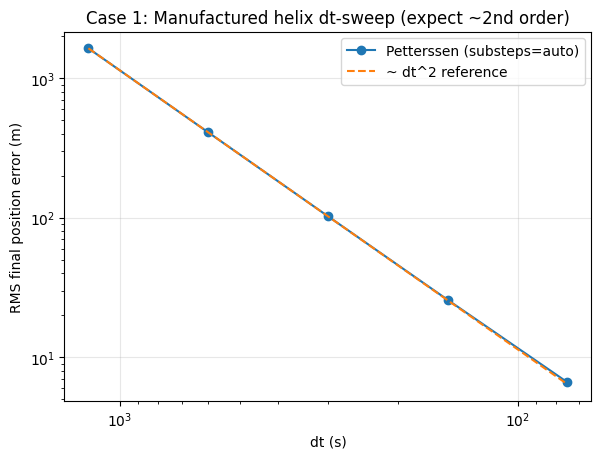

In [8]:
# -----------------------------
# Case 1: log-log convergence plot
# -----------------------------
plt.figure(figsize=(6.8, 4.8))
plt.loglog(dt_list, errs, marker='o', label='Petterssen (substeps=auto)')

ref_c = errs[0] / (dt_list[0] ** 2)
ref = [ref_c * (dt ** 2) for dt in dt_list]
plt.loglog(dt_list, ref, linestyle='--', label='~ dt^2 reference')

plt.gca().invert_xaxis()
plt.xlabel('dt (s)')
plt.ylabel('RMS final position error (m)')
plt.title('Case 1: Manufactured helix dt-sweep (expect ~2nd order)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# -----------------------------
# Case 1b: substep sensitivity and error attribution
# -----------------------------
dt_probe = 1200.0
time_probe = make_time_grid(dt_probe, t_end)
u_probe, v_probe, w_probe = build_wind_fields(time_probe)

substeps_probe = [1, 6, 12, 24, 48]
substep_sensitivity_case1b = {}

for sub in substeps_probe:
    traj_sub, status_sub = run_petterssen_forward(
        time_probe,
        u_probe,
        v_probe,
        w_probe,
        init_points_local=init_points,
        alt_grid_local=alt_grid,
        lat_grid_local=lat_grid,
        lon_grid_local=lon_grid,
        lower_boundary_local=lower_boundary,
        upper_boundary_local=upper_boundary,
        substeps=sub,
    )
    assert_all_active(status_sub, time_probe, init_points, label=f'Case1b-sub{sub}')
    substep_sensitivity_case1b[sub] = rms_final_error(traj_sub, t_end, init_points)

auto_traj, auto_status = run_petterssen_forward(
    time_probe,
    u_probe,
    v_probe,
    w_probe,
    init_points_local=init_points,
    alt_grid_local=alt_grid,
    lat_grid_local=lat_grid,
    lon_grid_local=lon_grid,
    lower_boundary_local=lower_boundary,
    upper_boundary_local=upper_boundary,
    substeps=PROD_SUBSTEPS,
)
assert_all_active(auto_status, time_probe, init_points, label='Case1b-auto')
substep_sensitivity_case1b['auto'] = rms_final_error(auto_traj, t_end, init_points)

# Consistency: auto should match 12-substeps result in this implementation
if not np.isclose(substep_sensitivity_case1b['auto'], substep_sensitivity_case1b[12], rtol=1e-10, atol=1e-12):
    raise AssertionError(
        f"Expected auto ~= 12. Got auto={substep_sensitivity_case1b['auto']}, sub12={substep_sensitivity_case1b[12]}"
    )

err1 = substep_sensitivity_case1b[1]
erra = substep_sensitivity_case1b['auto']
err48 = substep_sensitivity_case1b[48]

if not (err1 > erra):
    raise AssertionError(f'Expected err(sub=1) > err(sub=auto), got {err1} vs {erra}')

improve_1_to_auto = err1 / erra
improve_auto_to_48 = erra / err48

gap_1_auto = err1 - erra
gap_auto_48 = erra - err48
if not (gap_auto_48 < gap_1_auto):
    raise AssertionError(
        f'Expected gap(auto->48) < gap(1->auto), got {gap_auto_48} vs {gap_1_auto}'
    )

print('\n=== Case 1b: Substep sensitivity at dt=1200 s ===')
for key in [1, 6, 12, 24, 48, 'auto']:
    print(f'substeps={key:>4} | RMS final error = {substep_sensitivity_case1b[key]:.6e} m')

print('\nAttribution indicators:')
print(f'improve_1_to_auto   = {improve_1_to_auto:.4f}x')
print(f'improve_auto_to_48  = {improve_auto_to_48:.4f}x')
print(f'gap(1->auto)        = {gap_1_auto:.6e} m')
print(f'gap(auto->48)       = {gap_auto_48:.6e} m')
print(
    'Interpretation: large gain from 1->auto plus much smaller gain from auto->48 '
    'indicates current residual is dominated more by interpolation/discretization floor '
    'than by basic time-stepping truncation.'
)

# free local case1b arrays

del u_probe, v_probe, w_probe, auto_traj, auto_status


=== Case 1b: Substep sensitivity at dt=1200 s ===
substeps=   1 | RMS final error = 1.777052e+05 m
substeps=   6 | RMS final error = 5.132572e+03 m
substeps=  12 | RMS final error = 1.636466e+03 m
substeps=  24 | RMS final error = 1.094223e+03 m
substeps=  48 | RMS final error = 1.051022e+03 m
substeps=auto | RMS final error = 1.636466e+03 m

Attribution indicators:
improve_1_to_auto   = 108.5908x
improve_auto_to_48  = 1.5570x
gap(1->auto)        = 1.760687e+05 m
gap(auto->48)       = 5.854431e+02 m
Interpretation: large gain from 1->auto plus much smaller gain from auto->48 indicates current residual is dominated more by interpolation/discretization floor than by basic time-stepping truncation.



=== Case 2: 2D comparison metrics (dt_vis = 1200.0 s, substeps=auto) ===
pid        init (lon, lat, alt_m)    Petterssen final/max error (m)
0    ( 350.00,   0.00,   5000.0) 1.635533e+03 / 1.671157e+03
1    (  10.00,   1.00,   8000.0) 1.637158e+03 / 1.672731e+03
2    ( 180.00,  -2.00,  10000.0) 1.636705e+03 / 1.672682e+03


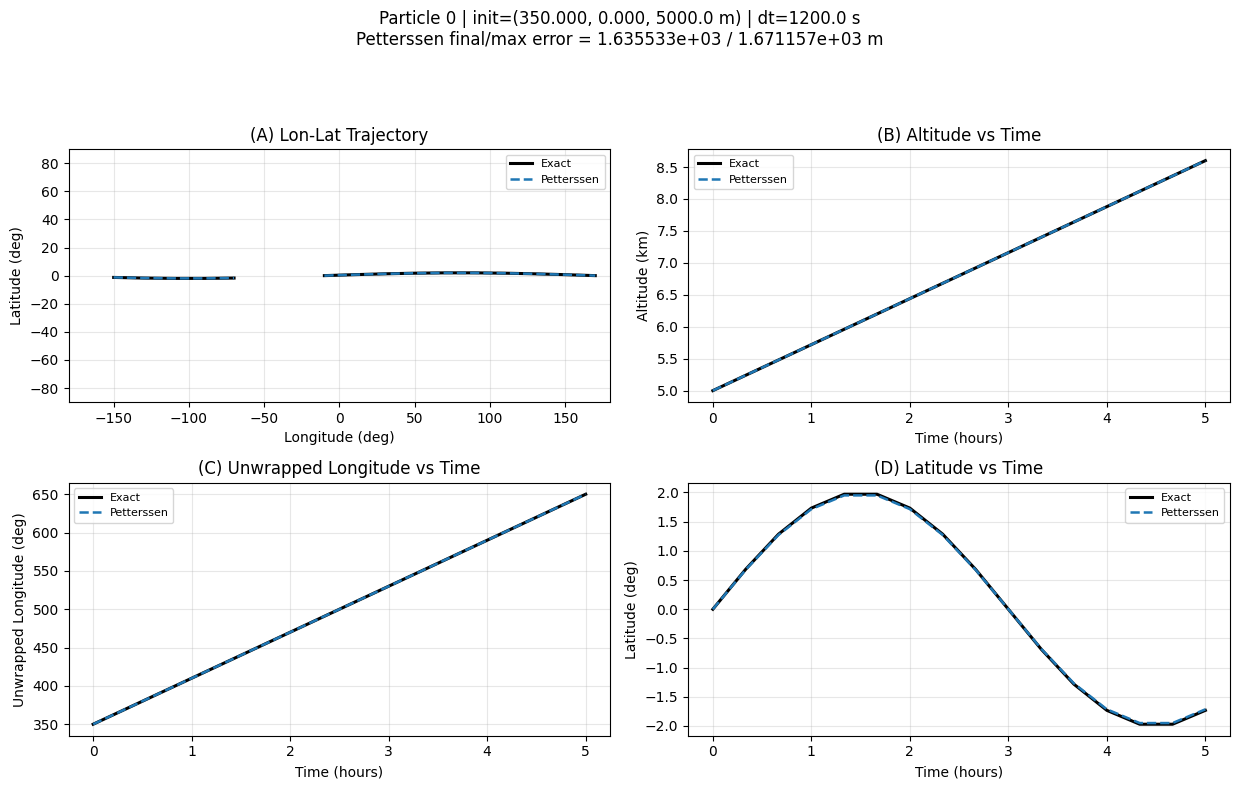

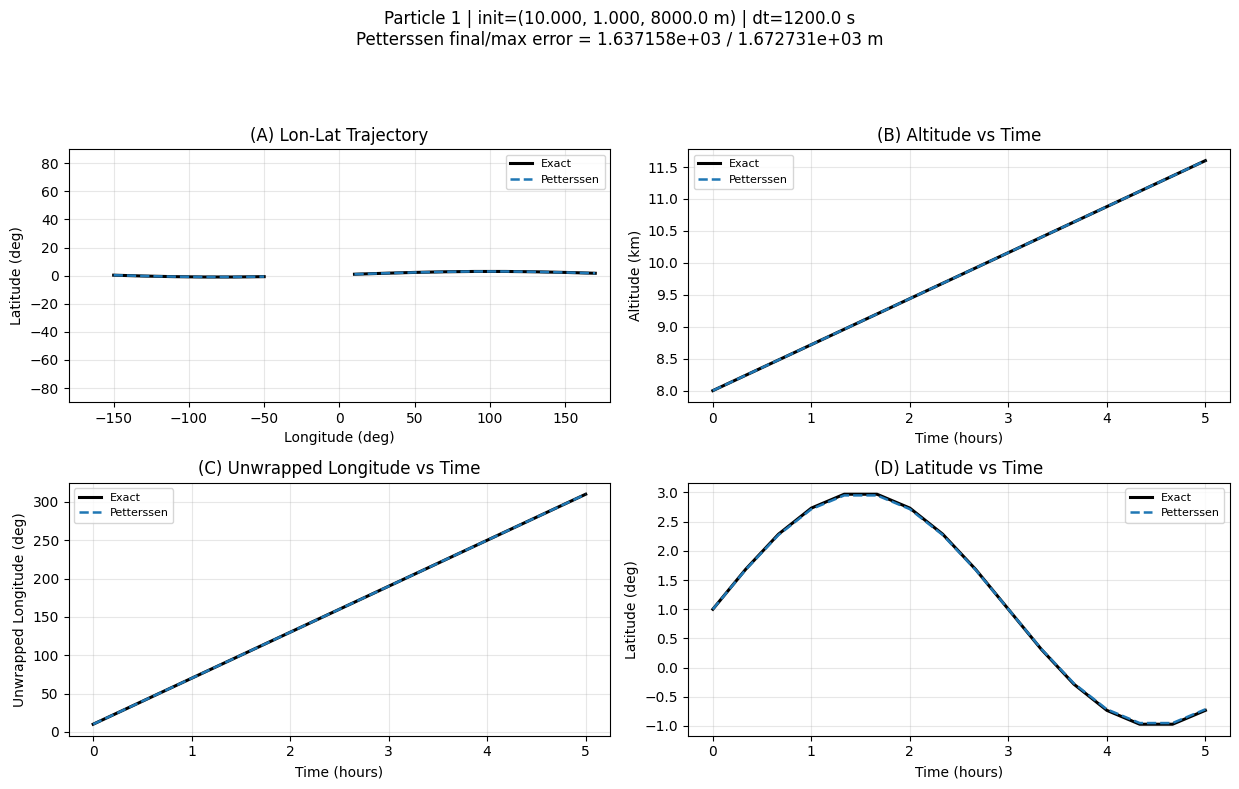

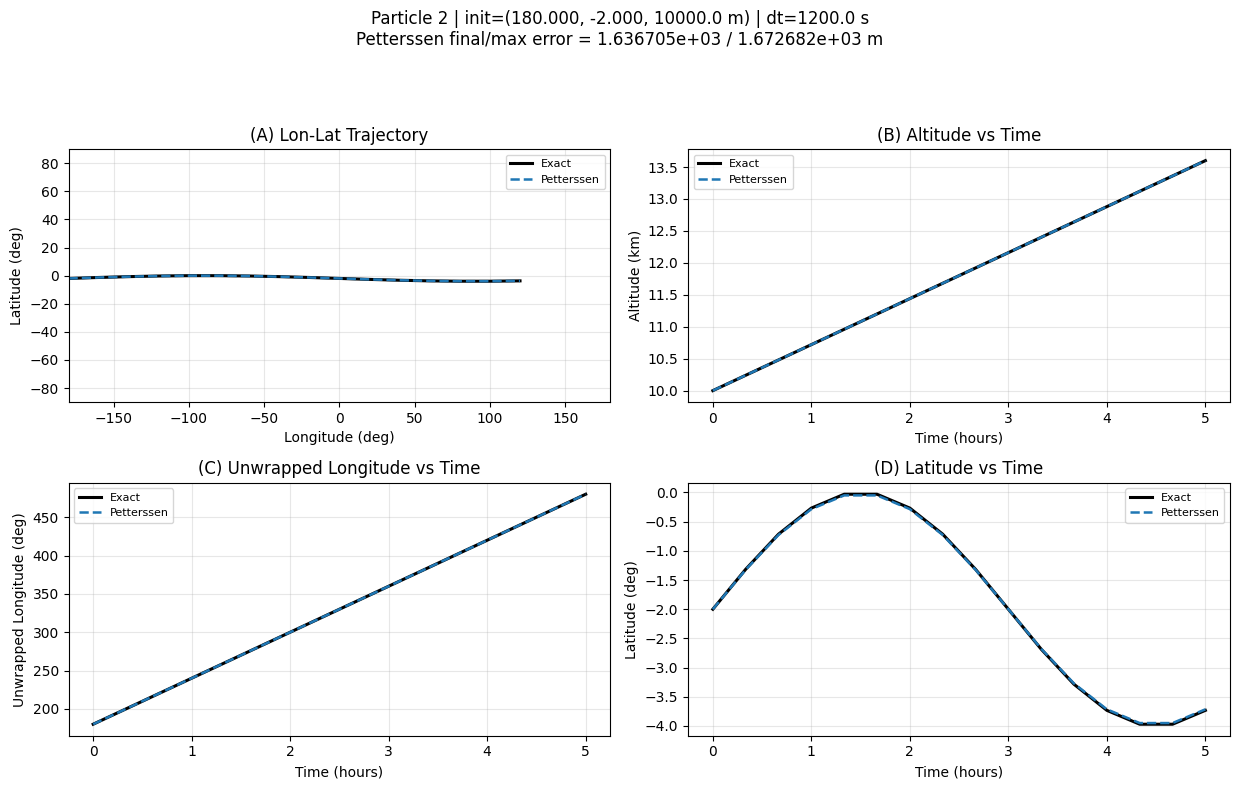

In [10]:
# -----------------------------
# Case 2: 2D trajectory comparison (Exact vs Petterssen, production substeps)
# -----------------------------
dt_vis = 1200.0
time_vis = make_time_grid(dt_vis, t_end)

u_vis, v_vis, w_vis = build_wind_fields(time_vis)
traj_vis, status_vis = run_petterssen_forward(
    time_vis,
    u_vis,
    v_vis,
    w_vis,
    init_points_local=init_points,
    alt_grid_local=alt_grid,
    lat_grid_local=lat_grid,
    lon_grid_local=lon_grid,
    lower_boundary_local=lower_boundary,
    upper_boundary_local=upper_boundary,
    substeps=PROD_SUBSTEPS,
)
assert_all_active(status_vis, time_vis, init_points, label='Case2')

compare_payload = {}
rows = []

for pid, init_point in enumerate(init_points):
    lon_ex, lat_ex, alt_ex = exact_helix(time_vis, *init_point)
    exact_series = (
        np.asarray(lon_ex, dtype=np.float64),
        np.asarray(lat_ex, dtype=np.float64),
        np.asarray(alt_ex, dtype=np.float64),
    )

    pet_series = extract_particle_series(traj_vis, init_points, pid, include_initial=True)
    if pet_series[0].shape[0] != time_vis.shape[0]:
        raise AssertionError(f'Case2 series length mismatch for pid={pid}')

    pet_err = compute_path_error_m(pet_series, exact_series)
    metrics = {
        'petterssen_final_error_m': _last_finite(pet_err),
        'petterssen_max_error_m': _max_finite(pet_err),
    }

    if not (np.isfinite(metrics['petterssen_final_error_m']) and np.isfinite(metrics['petterssen_max_error_m'])):
        raise AssertionError(f'Case2 metrics contain non-finite values for pid={pid}: {metrics}')

    compare_payload[pid] = {
        'case_name': 'case2',
        'init_point': init_point,
        'exact': exact_series,
        'petterssen': pet_series,
        'pet_err': pet_err,
        'metrics': metrics,
    }
    rows.append((pid, init_point, metrics))

print('\n=== Case 2: 2D comparison metrics (dt_vis = {:.1f} s, substeps={}) ==='.format(dt_vis, PROD_SUBSTEPS))
print('{:<4s} {:>28s} {:>33s}'.format('pid', 'init (lon, lat, alt_m)', 'Petterssen final/max error (m)'))
for pid, init_point, m in rows:
    print(
        '{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) {:>12.6e} / {:>12.6e}'.format(
            pid,
            float(init_point[0]),
            float(init_point[1]),
            float(init_point[2]),
            m['petterssen_final_error_m'],
            m['petterssen_max_error_m'],
        )
    )

for pid in range(len(init_points)):
    payload = compare_payload[pid]
    plot_compare_particle_2d(
        pid=pid,
        time_s=time_vis,
        exact=payload['exact'],
        pet=payload['petterssen'],
        init_point=payload['init_point'],
        metrics=payload['metrics'],
    )

# free large arrays from this case

del u_vis, v_vis, w_vis


=== Case 3: 3D metrics (dt_3d = 300.0 s, t_end_3d = 18.0 h, substeps=auto) ===
pid        init (lon, lat, alt_m)    Petterssen final/max error (m)
0    ( 350.00,   0.00,   5000.0) 2.846277e+02 / 2.846277e+02
1    (  10.00,   1.00,   8000.0) 2.848342e+02 / 2.848342e+02
2    ( 180.00,  -2.00,  10000.0) 2.848702e+02 / 2.848702e+02


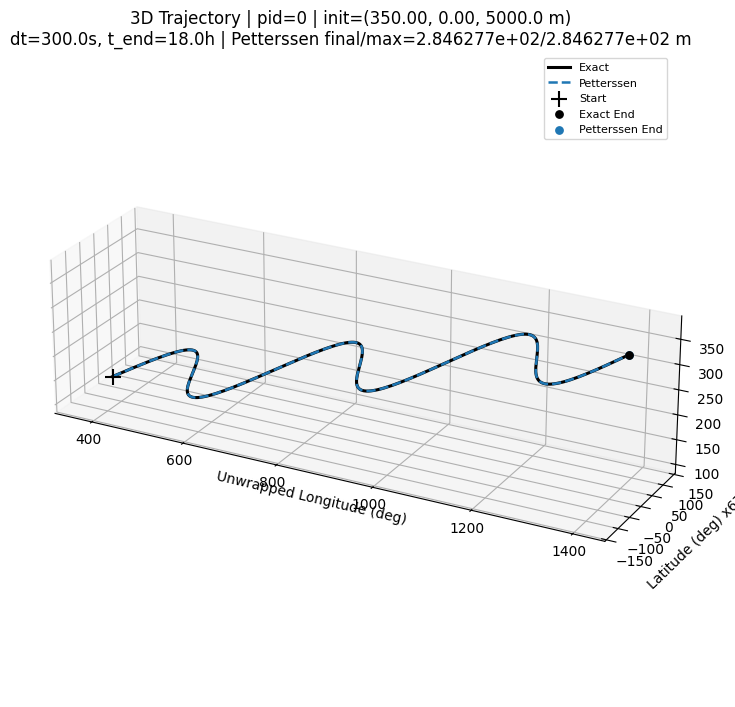

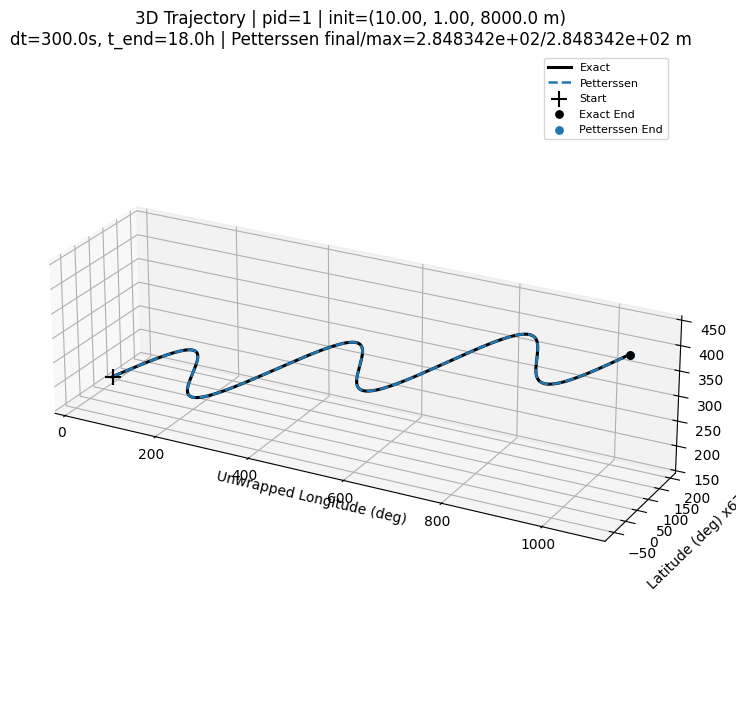

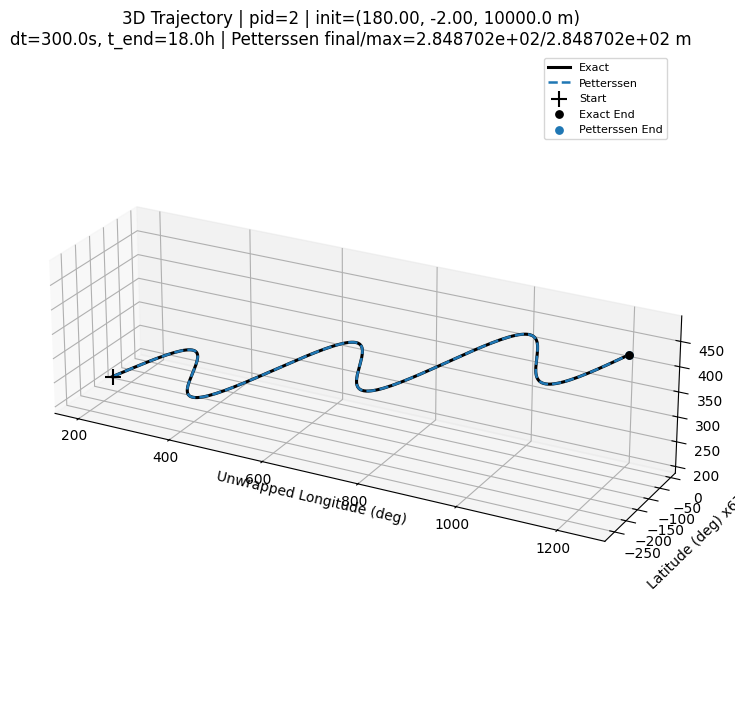

In [11]:
# -----------------------------
# Case 3: 3D trajectory comparison (Exact vs Petterssen, production substeps)
# -----------------------------
def _combined_range(*arrays):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=np.float64)
        finite = np.isfinite(arr)
        if np.any(finite):
            vals.append(arr[finite])
    if not vals:
        return np.nan
    merged = np.concatenate(vals)
    return float(np.nanmax(merged) - np.nanmin(merged))


def _combined_limits(*arrays, pad_frac=0.06, min_span=1.0):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=np.float64)
        finite = np.isfinite(arr)
        if np.any(finite):
            vals.append(arr[finite])

    if not vals:
        return (-1.0, 1.0)

    merged = np.concatenate(vals)
    vmin = float(np.nanmin(merged))
    vmax = float(np.nanmax(merged))

    span = vmax - vmin
    if span < min_span:
        center = 0.5 * (vmax + vmin)
        half = 0.5 * min_span
        vmin = center - half
        vmax = center + half
        span = min_span

    pad = pad_frac * span
    return (vmin - pad, vmax + pad)


def _safe_last_xyz(x, y, z):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    z = np.asarray(z, dtype=np.float64)
    idx = np.where(np.isfinite(x) & np.isfinite(y) & np.isfinite(z))[0]
    if idx.size == 0:
        return (np.nan, np.nan, np.nan)
    i = idx[-1]
    return (float(x[i]), float(y[i]), float(z[i]))


def plot_compare_particle_3d_exact_vs_pet(pid, time_s, exact, pet, init_point, metrics, scaling='enhanced'):
    time_s = np.asarray(time_s, dtype=np.float64)
    if time_s.ndim != 1:
        raise ValueError('time_s must be 1-D')

    lon_ex, lat_ex, alt_ex = exact
    lon_p, lat_p, alt_p = pet

    x_ex = unwrap_lon_deg(lon_ex)
    x_p = unwrap_lon_deg(lon_p)

    y_ex = np.asarray(lat_ex, dtype=np.float64)
    y_p = np.asarray(lat_p, dtype=np.float64)

    z_ex = np.asarray(alt_ex, dtype=np.float64) / 1000.0
    z_p = np.asarray(alt_p, dtype=np.float64) / 1000.0

    lat_gain = 1.0
    alt_gain = 1.0

    if scaling == 'enhanced':
        x_rng = _combined_range(x_ex, x_p)
        y_rng = _combined_range(y_ex, y_p)
        z_rng = _combined_range(z_ex, z_p)

        target = x_rng * 0.25 if np.isfinite(x_rng) and x_rng > 0.0 else 1.0

        lat_gain = float(np.clip(target / max(y_rng, 1e-9), 1.0, 120.0))
        alt_gain = float(np.clip(target / max(z_rng, 1e-9), 1.0, 120.0))

    y_ex_vis = y_ex * lat_gain
    y_p_vis = y_p * lat_gain

    z_ex_vis = z_ex * alt_gain
    z_p_vis = z_p * alt_gain

    fig = plt.figure(figsize=(10.2, 7.8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(x_ex, y_ex_vis, z_ex_vis, color='k', linestyle='-', linewidth=2.2, label='Exact')
    ax.plot(x_p, y_p_vis, z_p_vis, color='tab:blue', linestyle='--', linewidth=1.8, label='Petterssen')

    x_start = float(x_ex[0]) if np.isfinite(x_ex[0]) else np.nan
    y_start = float(y_ex_vis[0]) if np.isfinite(y_ex_vis[0]) else np.nan
    z_start = float(z_ex_vis[0]) if np.isfinite(z_ex_vis[0]) else np.nan
    if np.isfinite(x_start) and np.isfinite(y_start) and np.isfinite(z_start):
        ax.scatter([x_start], [y_start], [z_start], color='k', marker='+', s=120, label='Start')

    ex_end = _safe_last_xyz(x_ex, y_ex_vis, z_ex_vis)
    pe_end = _safe_last_xyz(x_p, y_p_vis, z_p_vis)

    if np.all(np.isfinite(ex_end)):
        ax.scatter([ex_end[0]], [ex_end[1]], [ex_end[2]], color='k', marker='o', s=28, label='Exact End')
    if np.all(np.isfinite(pe_end)):
        ax.scatter([pe_end[0]], [pe_end[1]], [pe_end[2]], color='tab:blue', marker='o', s=28, label='Petterssen End')

    xlim = _combined_limits(x_ex, x_p, pad_frac=0.03, min_span=5.0)
    ylim = _combined_limits(y_ex_vis, y_p_vis, pad_frac=0.08, min_span=1.0)
    zlim = _combined_limits(z_ex_vis, z_p_vis, pad_frac=0.08, min_span=1.0)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)

    xspan = max(xlim[1] - xlim[0], 1e-9)
    yspan = max(ylim[1] - ylim[0], 1e-9)
    zspan = max(zlim[1] - zlim[0], 1e-9)
    try:
        ax.set_box_aspect((xspan, yspan, zspan))
    except Exception:
        pass

    ax.set_xlabel('Unwrapped Longitude (deg)')
    ax.set_ylabel(f'Latitude (deg) x{lat_gain:.1f}')
    ax.set_zlabel(f'Altitude (km) x{alt_gain:.1f}')

    dt_local = float(time_s[1] - time_s[0]) if time_s.size >= 2 else np.nan
    ax.set_title(
        (
            f'3D Trajectory | pid={pid} | init=({float(init_point[0]):.2f}, {float(init_point[1]):.2f}, {float(init_point[2]):.1f} m)\n'
            f'dt={dt_local:.1f}s, t_end={float(time_s[-1] / 3600.0):.1f}h | '
            f'Petterssen final/max={metrics["petterssen_final_error_m"]:.6e}/{metrics["petterssen_max_error_m"]:.6e} m'
        )
    )

    ax.view_init(elev=24, azim=-62)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])
    plt.show()


dt_3d = 300.0
t_end_3d = 18.0 * 3600.0
time_3d = make_time_grid(dt_3d, t_end_3d)

alt_grid_3d = np.linspace(0.0, 30000.0, 16, dtype=np.float64)
lat_grid_3d = lat_grid
lon_grid_3d = lon_grid
lower_boundary_3d = float(alt_grid_3d.min())
upper_boundary_3d = float(alt_grid_3d.max())

u_3d, v_3d, w_3d = build_wind_fields(
    time_3d,
    alt_grid_local=alt_grid_3d,
    lat_grid_local=lat_grid_3d,
    lon_grid_local=lon_grid_3d,
)

traj_3d, status_3d = run_petterssen_forward(
    time_3d,
    u_3d,
    v_3d,
    w_3d,
    init_points_local=init_points,
    alt_grid_local=alt_grid_3d,
    lat_grid_local=lat_grid_3d,
    lon_grid_local=lon_grid_3d,
    lower_boundary_local=lower_boundary_3d,
    upper_boundary_local=upper_boundary_3d,
    substeps=PROD_SUBSTEPS,
)
assert_all_active(status_3d, time_3d, init_points, label='Case3')

compare_payload_3d = {}
rows_3d = []

for pid, init_point in enumerate(init_points):
    lon_ex, lat_ex, alt_ex = exact_helix(time_3d, *init_point)
    exact_series = (
        np.asarray(lon_ex, dtype=np.float64),
        np.asarray(lat_ex, dtype=np.float64),
        np.asarray(alt_ex, dtype=np.float64),
    )

    pet_series = extract_particle_series(traj_3d, init_points, pid, include_initial=True)
    if pet_series[0].shape[0] != time_3d.shape[0]:
        raise AssertionError(f'Case3 series length mismatch for pid={pid}')

    pet_err = compute_path_error_m(pet_series, exact_series)
    metrics = {
        'petterssen_final_error_m': _last_finite(pet_err),
        'petterssen_max_error_m': _max_finite(pet_err),
    }

    if not (np.isfinite(metrics['petterssen_final_error_m']) and np.isfinite(metrics['petterssen_max_error_m'])):
        raise AssertionError(f'Case3 metrics contain non-finite values for pid={pid}: {metrics}')

    compare_payload_3d[pid] = {
        'case_name': 'case3',
        'init_point': init_point,
        'exact': exact_series,
        'petterssen': pet_series,
        'pet_err': pet_err,
        'metrics': metrics,
    }
    rows_3d.append((pid, init_point, metrics))

print('\n=== Case 3: 3D metrics (dt_3d = {:.1f} s, t_end_3d = {:.1f} h, substeps={}) ==='.format(dt_3d, t_end_3d / 3600.0, PROD_SUBSTEPS))
print('{:<4s} {:>28s} {:>33s}'.format('pid', 'init (lon, lat, alt_m)', 'Petterssen final/max error (m)'))
for pid, init_point, m in rows_3d:
    print(
        '{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) {:>12.6e} / {:>12.6e}'.format(
            pid,
            float(init_point[0]),
            float(init_point[1]),
            float(init_point[2]),
            m['petterssen_final_error_m'],
            m['petterssen_max_error_m'],
        )
    )

for pid in range(len(init_points)):
    payload = compare_payload_3d[pid]
    plot_compare_particle_3d_exact_vs_pet(
        pid=pid,
        time_s=time_3d,
        exact=payload['exact'],
        pet=payload['petterssen'],
        init_point=payload['init_point'],
        metrics=payload['metrics'],
        scaling='enhanced',
    )

# free large arrays from this case

del u_3d, v_3d, w_3d


=== Case 4 (Lat70) metrics (dt_local = 1200.0 s, t_end_local = 5.0 h, substeps=auto) ===
pid        init (lon, lat, alt_m)  analytic lat min/max    Petterssen final/max error (m)
0    ( 350.00,   0.00,   5000.0) ( -68.937,   68.937) 3.714160e+04 / 4.226367e+04
1    (  10.00,   1.00,   8000.0) ( -67.937,   69.937) 3.716310e+04 / 4.231283e+04
2    ( 180.00,  -2.00,  10000.0) ( -70.937,   66.937) 3.721972e+04 / 4.233363e+04
[Note] dt_local=1200s uses discrete samples: sampled positive peak is about +68.94 deg; continuous target amplitude is +/-70.00 deg.


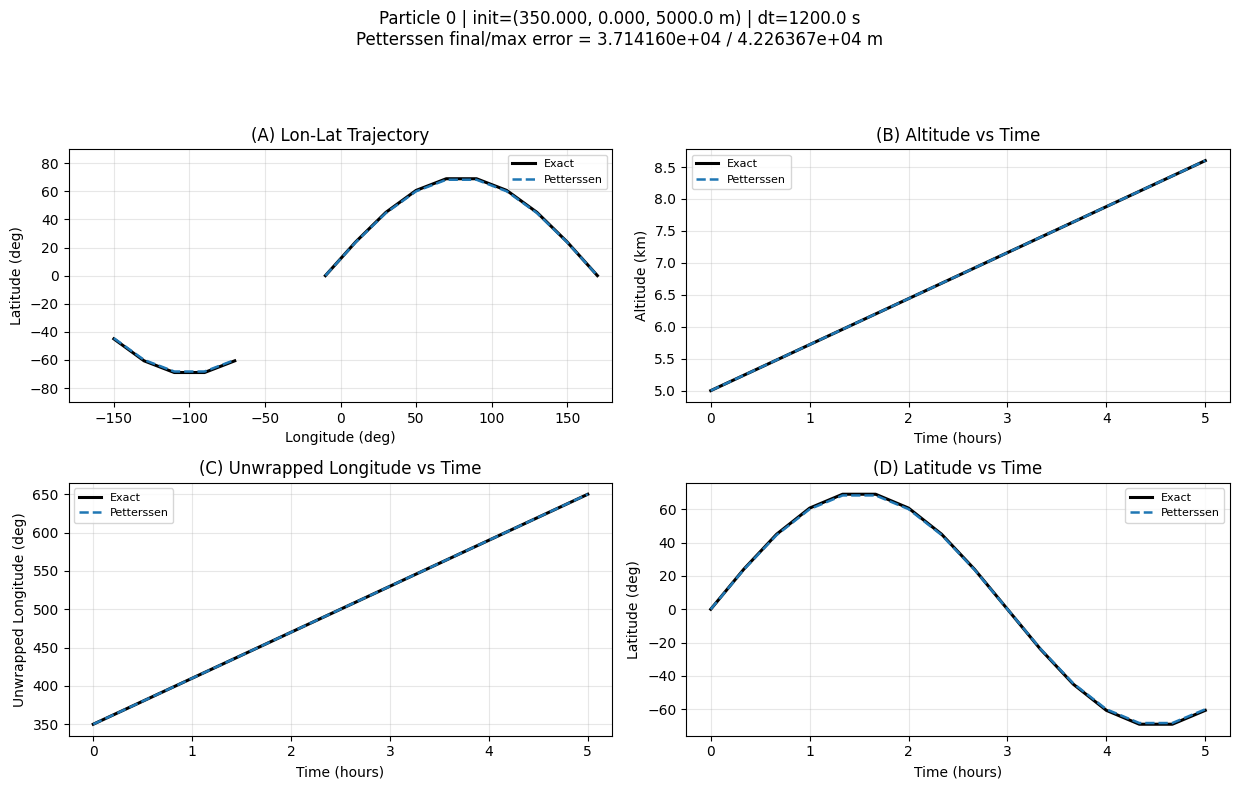

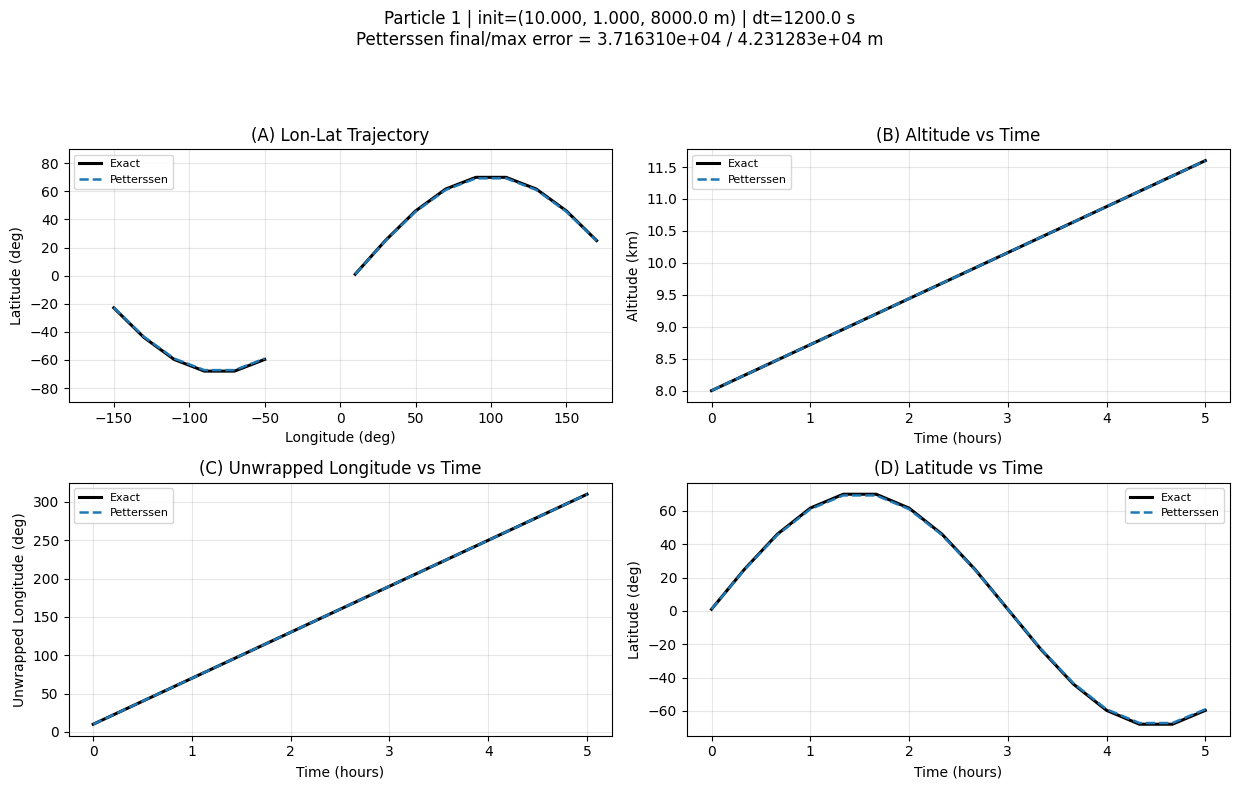

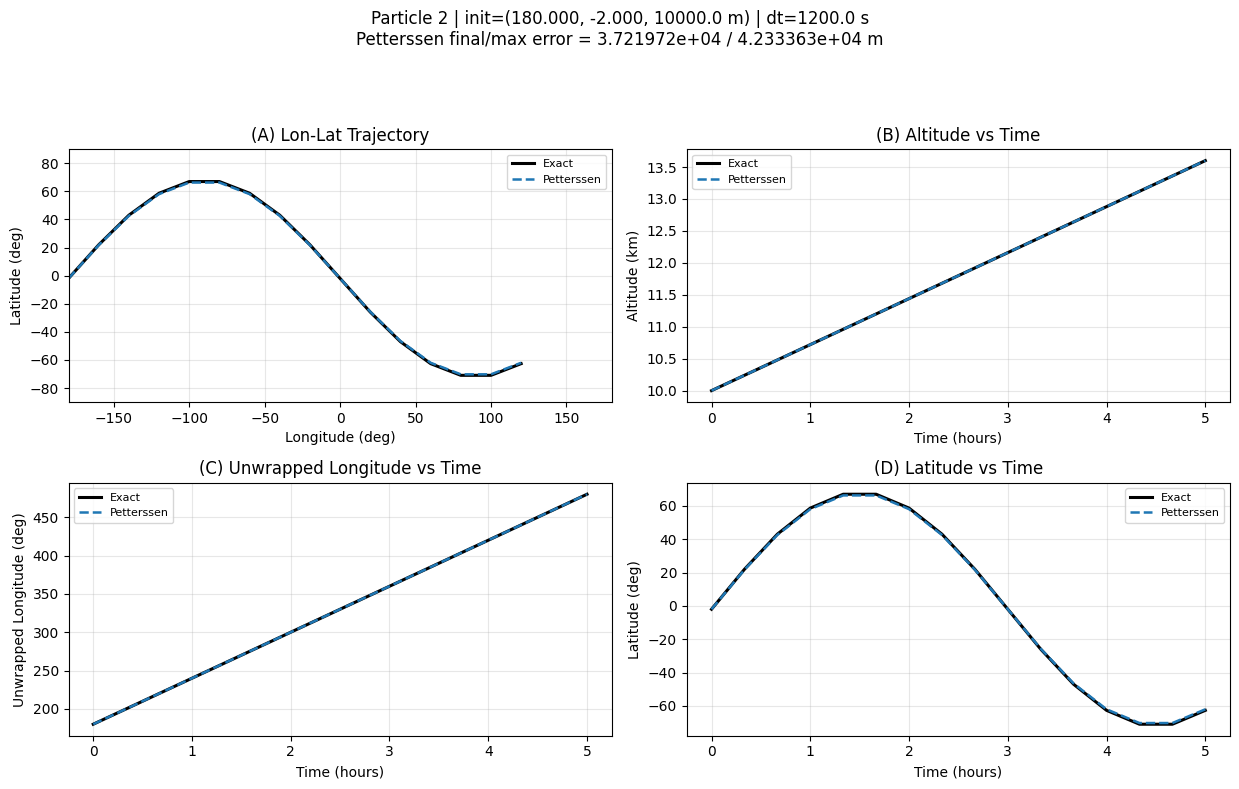

In [12]:
# -----------------------------
# Case 4: Lat70 high-latitude stress test (Exact vs Petterssen, production substeps)
# -----------------------------
A_deg_local = 70.0
A_local = np.deg2rad(A_deg_local)
dt_local = 1200.0
t_end_local = t_end

time_local = make_time_grid(dt_local, t_end_local)


def exact_helix_lat70(t, lon0_deg, lat0_deg, alt0_m):
    return exact_helix(t, lon0_deg, lat0_deg, alt0_m, A_deg_local=A_deg_local)


lon_grid_local = lon_grid
alt_grid_local = alt_grid
lat_grid_local = np.linspace(-80.0, 80.0, 641, dtype=np.float64)

lower_boundary_local = float(alt_grid_local.min())
upper_boundary_local = float(alt_grid_local.max())

u_local, v_local, w_local = build_wind_fields(
    time_local,
    alt_grid_local=alt_grid_local,
    lat_grid_local=lat_grid_local,
    lon_grid_local=lon_grid_local,
    A_rad_local=A_local,
)

traj_local, status_local = run_petterssen_forward(
    time_local,
    u_local,
    v_local,
    w_local,
    init_points_local=init_points,
    alt_grid_local=alt_grid_local,
    lat_grid_local=lat_grid_local,
    lon_grid_local=lon_grid_local,
    lower_boundary_local=lower_boundary_local,
    upper_boundary_local=upper_boundary_local,
    substeps=PROD_SUBSTEPS,
)
assert_all_active(status_local, time_local, init_points, label='Case4-Lat70')

compare_payload_local = {}
rows_local = []

for pid, init_point in enumerate(init_points):
    lon_ex, lat_ex, alt_ex = exact_helix_lat70(time_local, *init_point)
    exact_series = (
        np.asarray(lon_ex, dtype=np.float64),
        np.asarray(lat_ex, dtype=np.float64),
        np.asarray(alt_ex, dtype=np.float64),
    )

    pet_series = extract_particle_series(traj_local, init_points, pid, include_initial=True)
    if pet_series[0].shape[0] != time_local.shape[0]:
        raise AssertionError(f'Case4 series length mismatch for pid={pid}')

    pet_err = compute_path_error_m(pet_series, exact_series)
    metrics = {
        'petterssen_final_error_m': _last_finite(pet_err),
        'petterssen_max_error_m': _max_finite(pet_err),
    }

    if not (np.isfinite(metrics['petterssen_final_error_m']) and np.isfinite(metrics['petterssen_max_error_m'])):
        raise AssertionError(f'Case4 metrics contain non-finite values for pid={pid}: {metrics}')

    compare_payload_local[pid] = {
        'case_name': 'case4',
        'init_point': init_point,
        'exact': exact_series,
        'petterssen': pet_series,
        'pet_err': pet_err,
        'metrics': metrics,
    }

    rows_local.append((pid, init_point, float(np.nanmin(lat_ex)), float(np.nanmax(lat_ex)), metrics))

print('\n=== Case 4 (Lat70) metrics (dt_local = {:.1f} s, t_end_local = {:.1f} h, substeps={}) ==='.format(dt_local, t_end_local / 3600.0, PROD_SUBSTEPS))
print(
    '{:<4s} {:>28s} {:>21s} {:>33s}'.format(
        'pid',
        'init (lon, lat, alt_m)',
        'analytic lat min/max',
        'Petterssen final/max error (m)',
    )
)
for pid, init_point, lat_min, lat_max, m in rows_local:
    print(
        '{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) ({:8.3f}, {:8.3f}) {:>12.6e} / {:>12.6e}'.format(
            pid,
            float(init_point[0]),
            float(init_point[1]),
            float(init_point[2]),
            lat_min,
            lat_max,
            m['petterssen_final_error_m'],
            m['petterssen_max_error_m'],
        )
    )

sampled_peak = float(np.max(np.sin(Omega * time_local)) * A_deg_local)
print(
    '[Note] dt_local={:.0f}s uses discrete samples: sampled positive peak is about +{:.2f} deg; '
    'continuous target amplitude is +/-{:.2f} deg.'.format(dt_local, sampled_peak, A_deg_local)
)

for pid in range(len(init_points)):
    payload = compare_payload_local[pid]
    plot_compare_particle_2d(
        pid=pid,
        time_s=time_local,
        exact=payload['exact'],
        pet=payload['petterssen'],
        init_point=payload['init_point'],
        metrics=payload['metrics'],
    )

# free large arrays from this case

del u_local, v_local, w_local


=== Case 4 (Lat70) 3D metrics (enhanced scaling) ===
pid        init (lon, lat, alt_m)    Petterssen final/max error (m)
0    ( 350.00,   0.00,   5000.0) 3.714160e+04 / 4.226367e+04


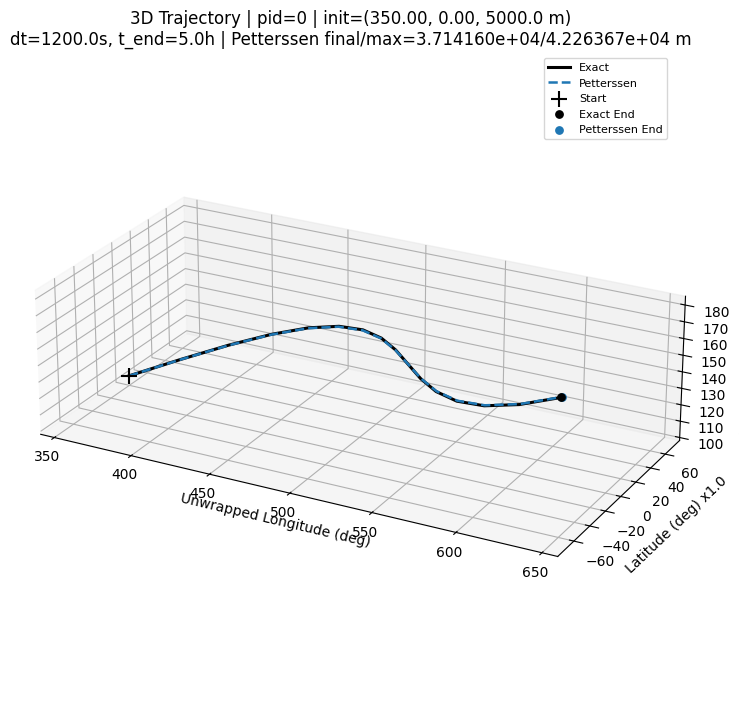

1    (  10.00,   1.00,   8000.0) 3.716310e+04 / 4.231283e+04


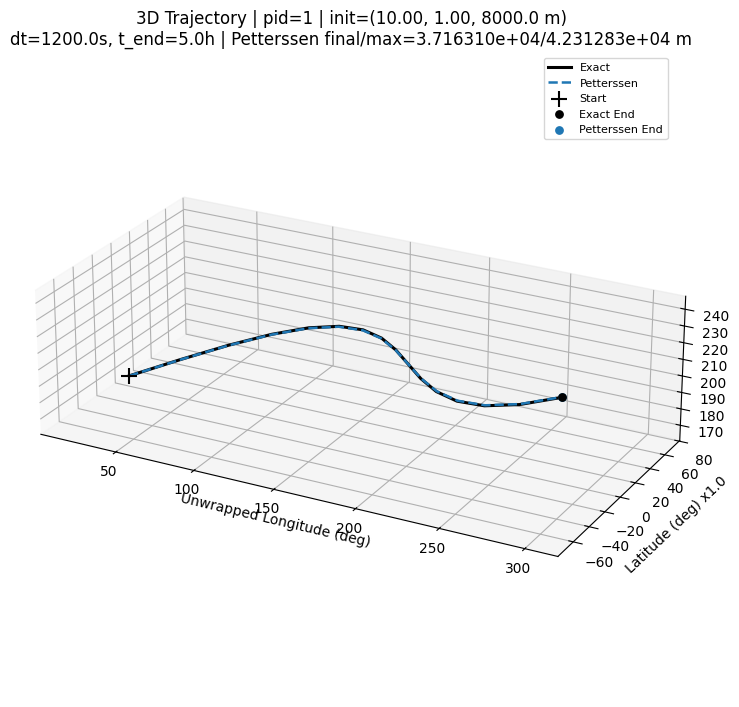

2    ( 180.00,  -2.00,  10000.0) 3.721972e+04 / 4.233363e+04


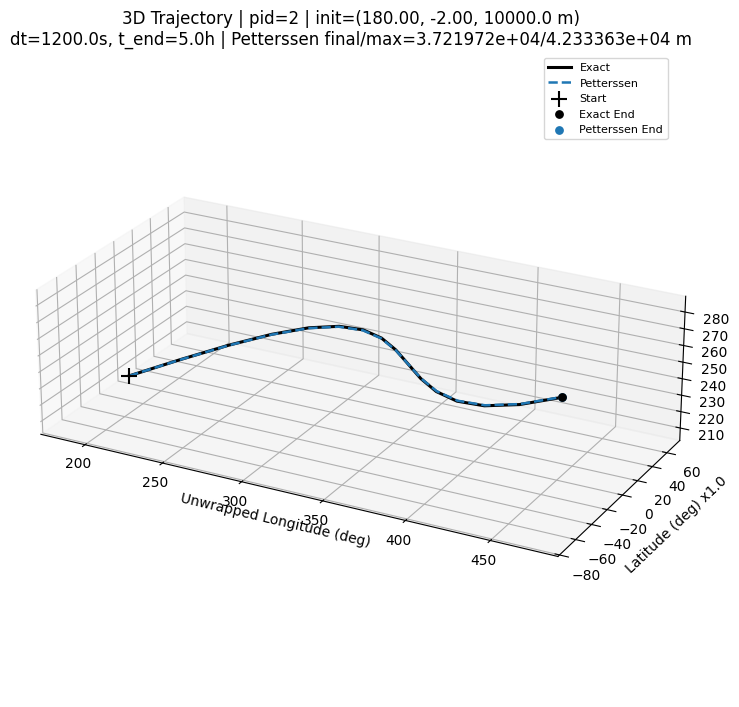

In [13]:
# -----------------------------
# Case 4 (Lat70): 3D visualization
# -----------------------------
required_symbols = [
    'time_local',
    'init_points',
    'compare_payload_local',
    'plot_compare_particle_3d_exact_vs_pet',
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing required objects for Case4-Lat70 3D visualization: '
        + ', '.join(missing)
        + '. Run previous cells first.'
    )

if len(compare_payload_local) != len(init_points):
    raise ValueError('compare_payload_local size mismatch; rerun Case4 cell first.')

print('\n=== Case 4 (Lat70) 3D metrics (enhanced scaling) ===')
print('{:<4s} {:>28s} {:>33s}'.format('pid', 'init (lon, lat, alt_m)', 'Petterssen final/max error (m)'))

for pid in range(len(init_points)):
    payload = compare_payload_local[pid]
    m = payload['metrics']
    p0 = payload['init_point']

    print(
        '{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) {:>12.6e} / {:>12.6e}'.format(
            pid,
            float(p0[0]),
            float(p0[1]),
            float(p0[2]),
            m['petterssen_final_error_m'],
            m['petterssen_max_error_m'],
        )
    )

    plot_compare_particle_3d_exact_vs_pet(
        pid=pid,
        time_s=time_local,
        exact=payload['exact'],
        pet=payload['petterssen'],
        init_point=payload['init_point'],
        metrics=payload['metrics'],
        scaling='enhanced',
    )

In [14]:
# -----------------------------
# Relative-error summary (final error normalized by exact path length)
# -----------------------------
def exact_path_length_m(exact_series):
    lon_ex, lat_ex, alt_ex = [np.asarray(a, dtype=np.float64) for a in exact_series]
    xyz = sph_to_xyz_vec(lon_ex, lat_ex, alt_ex)
    if xyz.shape[0] < 2:
        return np.nan
    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))


relative_error_summary = []

for case_name, payload_dict in [
    ('case2', compare_payload),
    ('case3', compare_payload_3d),
    ('case4', compare_payload_local),
]:
    for pid in sorted(payload_dict.keys()):
        payload = payload_dict[pid]
        final_err_m = float(payload['metrics']['petterssen_final_error_m'])
        path_len_m = exact_path_length_m(payload['exact'])
        rel = np.nan
        if np.isfinite(path_len_m) and path_len_m > 0.0:
            rel = final_err_m / path_len_m

        relative_error_summary.append({
            'case': case_name,
            'pid': int(pid),
            'final_error_km': final_err_m / 1000.0,
            'path_length_km': path_len_m / 1000.0 if np.isfinite(path_len_m) else np.nan,
            'relative_final_error_percent': rel * 100.0 if np.isfinite(rel) else np.nan,
        })

summary_table = relative_error_summary

print('\n=== Relative final error summary ===')
print('{:<8s} {:<4s} {:>14s} {:>15s} {:>15s}'.format('case', 'pid', 'final_err(km)', 'path_len(km)', 'final_err(%)'))
for row in relative_error_summary:
    print(
        '{:<8s} {:<4d} {:>14.6f} {:>15.6f} {:>15.6f}'.format(
            row['case'],
            row['pid'],
            row['final_error_km'],
            row['path_length_km'],
            row['relative_final_error_percent'],
        )
    )


=== Relative final error summary ===
case     pid   final_err(km)    path_len(km)    final_err(%)
case2    0          1.635533    17726.858187        0.009226
case2    1          1.637158    17738.765641        0.009229
case2    2          1.636705    17744.134862        0.009224
case3    0          0.284628    64212.876116        0.000443
case3    1          0.284834    64259.632138        0.000443
case3    2          0.284870    64267.927909        0.000443
case4    0         37.141601    17240.752179        0.215429
case4    1         37.163104    17235.456196        0.215620
case4    2         37.219720    17304.793644        0.215083


## Conclusion

- Production stepping is enabled in this notebook: `substeps='auto'`.
- Case 1b reports the relative contribution of substep refinement: if `1 -> auto` gives a large gain
  while `auto -> 48` gives a much smaller gain, the residual error is mainly controlled by interpolation/discretization floor.
- If further error reduction is needed, prioritize increasing wind-field temporal/spatial resolution or reducing case time step,
  rather than only increasing substeps indefinitely.

In [15]:
# Optional cleanup (default: keep results for post-analysis)
ENABLE_CLEANUP = False

if ENABLE_CLEANUP:
    removable_names = [
        'traj_vis', 'traj_3d', 'traj_local',
        'status_vis', 'status_3d', 'status_local',
        'compare_payload', 'compare_payload_3d', 'compare_payload_local',
        'rows', 'rows_3d', 'rows_local',
    ]
    for _name in removable_names:
        if _name in globals():
            del globals()[_name]
    print('Cleanup done (large objects removed; summaries retained).')
else:
    print('Cleanup skipped (ENABLE_CLEANUP=False).')

Cleanup skipped (ENABLE_CLEANUP=False).
